In [2]:
import argparse
import os
import random

import numpy as np
import pandas as pd
import torch

from exp.exp_custom import Exp_Custom
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast
from exp.exp_basic import Exp_Basic


In [3]:
# fix seed for reproducibility
fix_seed = 2021
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)
torch.set_num_threads(6)

# basic config
config = {
    # dataset settings
    'root_path': '../data/processed/',
    'data_path': 'softs_cleaned_data.csv',
    'data': 'all_stocks_and_S&P_500',
    'features': 'M',
    'freq': 'd',
    'seq_len': 30,
    'pred_len': 14,
    # model settings
    'model': 'SOFTS',
    'checkpoints': './checkpoints/',
    'd_model': 128,
    'd_core': 64,
    'd_ff': 128,
    'e_layers': 2,
    'learning_rate': 0.0003,
    'lradj': 'cosine',
    'train_epochs': 50,
    'patience': 3,
    'batch_size': 16,
    'dropout': 0.0,
    'activation': 'gelu',
    'use_norm': True,
    # system settings
    'num_workers': 0,
    'use_gpu': True,
    'gpu': '0',
    'save_model': True,
    #long term forecasting settings
    #'use_multi_gpu': False,
    #'devices': '0'
}

parser = argparse.ArgumentParser(description='SOFTS')
args = parser.parse_args([])
args.__dict__.update(config)
args.use_gpu = True if torch.cuda.is_available() and args.use_gpu else False

print('Args in experiment:')
print(args)

Args in experiment:
Namespace(root_path='../data/processed/', data_path='softs_cleaned_data.csv', data='all_stocks_and_S&P_500', features='M', freq='d', seq_len=30, pred_len=14, model='SOFTS', checkpoints='./checkpoints/', d_model=128, d_core=64, d_ff=128, e_layers=2, learning_rate=0.0003, lradj='cosine', train_epochs=50, patience=3, batch_size=16, dropout=0.0, activation='gelu', use_norm=True, num_workers=0, use_gpu=False, gpu='0', save_model=True)


In [4]:
# load data
data = pd.read_csv(os.path.join(args.root_path, args.data_path))

if 'Date' in data.columns or 'date' in data.columns:
    date_col = 'Date' if 'Date' in data.columns else 'date'
    # Convert to datetime
    data[date_col] = pd.to_datetime(data[date_col])
    # Save dates before dropping for later use
    dates = data[date_col]
    data = data.drop(columns=[date_col])
print(data.head())

#split stock data
# total length
N = len(data)                   # 3019

# split points
train_end = int(N * 0.70)       # 70% train
val_end   = int(N * 0.85)       # next 15% val

#slice
train_data = data.iloc[: train_end]

vali_data  = data.iloc[train_end - args.seq_len : val_end]

test_data  = data.iloc[val_end - args.seq_len : ]

# optional: scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
if 'Date' in train_data.columns:
    scaler.fit(train_data.iloc[:, 1:])
    train_data.iloc[:, 1:] = scaler.transform(train_data.iloc[:, 1:])
    vali_data.iloc[:, 1:] = scaler.transform(vali_data.iloc[:, 1:])
    test_data.iloc[:, 1:] = scaler.transform(test_data.iloc[:, 1:])
else:
    scaler.fit(train_data.iloc[:, :])
    train_data.iloc[:, :] = scaler.transform(train_data.iloc[:, :])
    vali_data.iloc[:, :] = scaler.transform(vali_data.iloc[:, :])
    test_data.iloc[:, :] = scaler.transform(test_data.iloc[:, :])

    AABA   AAPL   AMZN    AXP     BA    CAT   CSCO    CVX    DIS     GE  ...  \
0  40.91  10.68  47.58  52.58  70.44  57.80  17.45  59.08  24.40  35.37  ...   
1  40.97  10.71  47.25  51.95  71.17  59.27  17.85  58.91  23.99  35.32  ...   
2  41.53  10.63  47.65  52.50  70.33  59.27  18.35  58.19  24.41  35.23  ...   
3  43.21  10.90  47.87  52.68  69.35  60.45  18.77  59.25  24.74  35.47  ...   
4  43.42  10.86  47.08  53.99  68.77  61.55  19.06  58.95  25.00  35.38  ...   

     NKE    PFE     PG      SP500    TRV    UNH    UTX     VZ    WMT    XOM  
0  10.74  23.78  58.78  88.224953  45.99  61.73  56.53  30.38  46.23  58.47  
1  10.69  24.55  58.89  88.642776  46.50  61.88  56.19  31.27  46.32  58.57  
2  10.76  24.58  58.70  88.698463  46.95  61.69  55.98  31.63  45.69  58.28  
3  10.72  24.85  58.64  89.436554  47.21  62.90  56.16  31.35  45.88  59.43  
4  10.88  24.85  59.08  89.666359  47.23  61.40  56.80  31.48  45.71  59.40  

[5 rows x 32 columns]


In [5]:
def preprocess_data(data):
    """
    Clean and preprocess data to prevent numerical issues
    """
    # Replace infinite values
    data = data.replace([np.inf, -np.inf], np.nan)
    
    # Fill NaN values with column means
    data = data.fillna(data.mean())
    
    # Clip extreme values
    for col in data.columns:
        q1 = data[col].quantile(0.01)
        q3 = data[col].quantile(0.99)
        data[col] = data[col].clip(q1, q3)
    
    return data

# Apply preprocessing
train_data = preprocess_data(train_data)
vali_data = preprocess_data(vali_data)
test_data = preprocess_data(test_data)

In [6]:
import types
import torch.nn.functional as F
from models.SOFTS import STAR

def patch_star_module(model):
    for module in model.modules():
        if hasattr(module, 'forward') and isinstance(module, STAR):
            original_forward = module.forward
            
            def safe_forward(self, input, *args, **kwargs):
                batch_size, channels, d_series = input.shape
                
                # Original code with minimal changes
                combined_mean = F.gelu(self.gen1(input))
                combined_mean = self.gen2(combined_mean)
                combined_mean = combined_mean - combined_mean.max(dim=1, keepdim=True)[0]
                
                if self.training:
                    # guardrails for torch.binomial
                    ratio = F.softmax(combined_mean, dim=1)
                    ratio = ratio.permute(0, 2, 1).reshape(-1, channels)
                    
                    # Fix for multinomial - ensure valid probabilities
                    ratio = torch.nan_to_num(ratio, nan=1e-10)
                    ratio = torch.abs(ratio) + 1e-10  # Ensure positive values
                    ratio = ratio / ratio.sum(dim=1, keepdim=True)  # Normalize
                    
                    indices = torch.multinomial(ratio, 1)
                    indices = indices.view(batch_size, -1, 1).permute(0, 2, 1)
                    combined_mean = torch.gather(combined_mean, 1, indices)
                    combined_mean = combined_mean.repeat(1, channels, 1)
                else:
                    # Keep inference code
                    weight = F.softmax(combined_mean, dim=1).clamp(min=1e-6)
                    weight = weight / weight.sum(dim=1, keepdim=True)
                    combined_mean = (combined_mean * weight).sum(dim=1, keepdim=True)
                    combined_mean = combined_mean.repeat(1, channels, 1)
                
                # Original fusion code
                combined_mean_cat = torch.cat([input, combined_mean], -1)
                combined_mean_cat = F.gelu(self.gen3(combined_mean_cat))
                combined_mean_cat = self.gen4(combined_mean_cat)
                
                return combined_mean_cat, None
                
            module.forward = types.MethodType(safe_forward, module)
    
    return model

In [9]:
Exp = Exp_Custom(args)
patch_star_module(Exp.model)
setting = f'{args.data}_{args.model}_{args.seq_len}_{args.pred_len}'

Use CPU


In [6]:


# train + test the model
print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
Exp.train(setting=setting, train_data=train_data, vali_data=vali_data, test_data=test_data)
print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
Exp.test(setting=setting, test_data=test_data)

Use CPU
>>>>>>>start training : all_stocks_and_S&P_500_SOFTS_30_14>>>>>>>>>>>>>>>>>>>>>>>>>>
	iters: 100, epoch: 1 | loss: 0.0298343
	speed: 0.2628s/iter; left time: 1681.8992s
Epoch: 1 cost time: 30.663299083709717
Validation loss decreased (inf --> 1.056525).  Saving model ...
Epoch: 1, Steps: 130 | Train Loss: 0.0298343 Vali Loss: 1.0565253 Test Loss: 0.3075500
Updating learning rate to 0.0002997040092642407
	iters: 100, epoch: 2 | loss: 0.0303696
	speed: 0.3337s/iter; left time: 2092.6523s
Epoch: 2 cost time: 28.62928080558777
Validation loss decreased (1.056525 --> 0.990147).  Saving model ...
Epoch: 2, Steps: 130 | Train Loss: 0.0303696 Vali Loss: 0.9901474 Test Loss: 0.2655924
Updating learning rate to 0.0002988172051971717
	iters: 100, epoch: 3 | loss: 0.2030390
	speed: 0.3172s/iter; left time: 1947.7398s
Epoch: 3 cost time: 26.560978889465332
Validation loss decreased (0.990147 --> 0.963914).  Saving model ...
Epoch: 3, Steps: 130 | Train Loss: 0.2030390 Vali Loss: 0.9639144 T

In [10]:
# get predictions
predictions = Exp.predict(setting=setting, pred_data=test_data)
print(predictions.shape)

loading model from ./checkpoints/all_stocks_and_S&P_500_SOFTS_30_14/checkpoint.pth
(454, 14, 32)


Scaled metrics (first day) - MAE: 0.0899
Scaled metrics (all days) - MAE: 0.1549


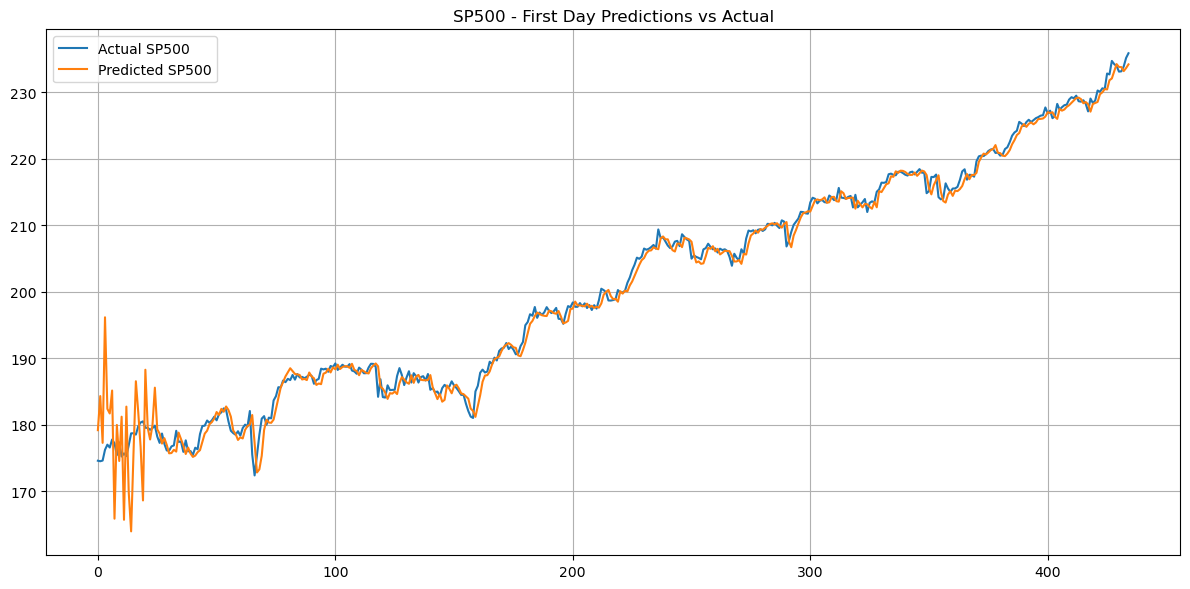

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get actual values for SP500 (column index for SP500)
sp500_col_idx = list(data.columns).index('SP500')

# Get predicted values for SP500 from all predictions
# predictions shape is (454, 14, 32) - samples, prediction length, features
predicted_sp500 = predictions[:, :, sp500_col_idx]

# The actual test data needs to be aligned with predictions
# We need to get the actual values that correspond to our prediction horizon
actual_sp500_values = []

# For each prediction starting point, collect the next 14 actual values
for i in range(len(predictions)):
    # Start from seq_len (where predictions begin) + i
    start_idx = args.seq_len + i
    if start_idx + args.pred_len <= len(test_data):
        actual_values = test_data.iloc[start_idx:start_idx+args.pred_len, sp500_col_idx].values
        actual_sp500_values.append(actual_values)

# Convert to numpy array
actual_sp500_array = np.array(actual_sp500_values)

# Make sure we're comparing same number of samples
min_samples = min(len(actual_sp500_array), len(predicted_sp500))
actual_sp500_array = actual_sp500_array[:min_samples]
predicted_sp500 = predicted_sp500[:min_samples]

# Calculate metrics for first day predictions
mae_first_day = mean_absolute_error(actual_sp500_array[:, 0], predicted_sp500[:, 0])

# Calculate metrics across all 14 days (flattened)
mae_all = mean_absolute_error(actual_sp500_array.flatten(), predicted_sp500.flatten())

# Inverse transform to get original scale values
# Create temporary arrays for inverse transformation
temp_actual = np.zeros((len(actual_sp500_array[:, 0]), len(data.columns)))
temp_actual[:, sp500_col_idx] = actual_sp500_array[:, 0]

temp_pred = np.zeros((len(predicted_sp500[:, 0]), len(data.columns)))
temp_pred[:, sp500_col_idx] = predicted_sp500[:, 0]

# Inverse transform
actual_original = scaler.inverse_transform(temp_actual)[:, sp500_col_idx]
predicted_original = scaler.inverse_transform(temp_pred)[:, sp500_col_idx]

# Print results
print(f"Scaled metrics (first day) - MAE: {mae_first_day:.4f}")
print(f"Scaled metrics (all days) - MAE: {mae_all:.4f}")

# Plot first day predictions 
plt.figure(figsize=(12, 6))
plt.plot(actual_original[5:], label='Actual SP500')
plt.plot(predicted_original[5:], label='Predicted SP500')
plt.title('SP500 - First Day Predictions vs Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()